# Phytclust Workflow

In [ ]:
from phytclust import PhytClust
from phytclust import plot_tree
from phytclust import pairwise_distances
import io
import os
from Bio import Phylo

In [ ]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
results_dir = "/home/ganesank/project/phytclust/results"  # change

## Importing 

In [ ]:
# With newick string
tree_string = "((((((((((((((A:1,B:1):1,C:1):1,D:1):1,E:1):3,F:1):1,G:1):1,H:1):1,I:1):1,J:1):1,K:1):1,L:1):1,M:1):1,N:1):1,O:1);"
# tree_string = "(OTR_human:0.3811057684,((OTR_chicken:0.0916417601,OTR_zebra_finch:0.2185888587)100:0.2038413592,(((OTR_wall_lizard:0.4020158148,(OTRb_zebrafish:0.2425260961,OTR_snake:0.4756226684)99:0.0818685058)100:0.2114707415,OTR_sea_turtle:0.4763870751)96:0.0957011482,((OTR_coelacanth:0.6487930020,((OTR_white_shark:0.3052001022,OTR_elephant_shark:0.3583541759)100:0.2168099597,(((((OTRa_clingfish:0.4203590544,(OTRa_zebrafish:0.2490518077,OTRa_eel:0.3377224960)100:0.2753551378)96:0.0751505407,OTRb_clingfish:0.5833534164)96:0.0639574775,(OTRb_eel:0.4751064450,OTR_spotted_gar:0.6065898938)96:0.1899103149)100:0.1111385650,(OTRa_piranha:0.4868642088,OTRb_piranha:0.5264311912)99:0.1559409589)69:0.0795794071,((((((V1Ab_piranha:0.8412031944,((V1Aa_zebrafish:0.3398284257,(V1Ab_zebrafish:0.2799920970,V1Ab_eel_exons:0.3652421656)100:0.1220260378)43:0.0492126453,(V1Aa_piranha:0.3564081277,V1Ab_clingfish:0.6053809714)53:0.0984397834)35:0.0180372180)48:0.0642140480,(V1Aa_clingfish:0.4224847894,(V1A_spotted_gar:0.5758225095,V1Aa_eel:0.7336201524)85:0.1375352011)76:0.0575276083)59:0.0802958547,(((V1A_human:0.5042827761,V1A_mouse:0.3767685558)100:0.2835137463,(((V1A_chicken:0.0796965655,V1A_zebra_finch:0.1540645581)100:0.1486805660,V1A_sea_turtle:0.1984452381)100:0.1040327116,(V1A_snake:0.2405625135,V1A_wall_lizard:0.1793105264)100:0.1871880929)100:0.1662101683)80:0.1036814609,(V1A_coelacanth:0.7929578303,V1A_frog:0.5409560521)54:0.1181536606)49:0.0560082713)41:0.0433069099,(V1A_elephant_shark:0.2959256193,V1A_white_shark:0.3033017072)100:0.4168409826)100:0.1970914675,(((V1B_coelacanth:0.5963023570,V1B_frog:0.8365014003)100:0.2519501060,((V1B_human:0.2849807425,V1B_mouse:0.2554161440)100:0.3508933367,((V1B_chicken:0.2765002817,V1B_zebra_finch:0.1421412715)100:0.0789781323,(V1B_sea_turtle:0.2180187648,(V1B_snake:0.3551038101,V1B_wall_lizard:0.1621107193)100:0.3079183415)95:0.0682930767)100:0.1998778770)100:0.3111257471)93:0.0448360566,V1B_elephant_shark:0.7455178498)100:0.1670559949)69:0.0538484962,(((OTRb_sea_lamprey:0.4510998010,OTRa_sea_lamprey:0.6538178312)93:0.1394533428,V1A_sea_lamprey:0.8075923630)100:0.1566192672,((((((((((V2A_chicken:0.1532023667,V2A_zebra_finch:0.1621898922)100:0.1417457584,V2A_sea_turtle:0.1704960516)100:0.1156101565,V2A_wall_lizard:0.4868537300)96:0.1049379690,V2A_frog:0.4410915959)100:0.2974804520,V2A_spotted_gar:0.7431509714)90:0.0983058927,V2A_elephant_shark:0.7814533780)100:0.2174467895,(((V2Aa_clingfish:0.5159503312,(V2Ab_zebrafish:0.1987597544,V2Ab_eel:0.4902344054)100:0.1846022384)100:0.4268637000,V2A_white_shark:0.8753997160)100:0.3599345416,(V2A_sea_lamprey:0.6539787252,V2B_sea_lamprey:0.6345402785)100:0.2005935268)96:0.0630700335)80:0.0586936512,((((V2B_spotted_gar:0.3307554119,V2B_coelacanth:0.6349068308)100:0.3165071250,V2Bb_clingfish:0.6040122628)85:0.0844661640,(V2Ba_zebrafish:0.5377089887,V2Ba_eel:0.6272980925)99:0.1901505764)73:0.0754084983,V2Ba_piranha:0.8420406172)99:0.1637381980)99:0.0570266363,((((((V2Ca_clingfish:0.4234248640,(V2Ca_piranha:0.2130525343,V2Ca_eel:0.2509524006)100:0.1682671516)100:0.2219925264,(V2Ca_zebrafish:0.5501446265,V2Cb_zebrafish:0.4115219692)100:0.2576704132)85:0.0447310010,(V2Cb_eel:0.3214308432,V2Cb_piranha:0.4039247614)100:0.1590777762)90:0.0579946381,V2Cb_clingfish:0.8729593664)100:0.1240954705,V2C_spotted_gar:0.6389245150)100:0.1124388084,((V2C_coelacanth:0.7679474287,V2C_frog:0.9384819782)100:0.1979732140,((V2C_human:0.1841739071,V2C_mouse:0.2291934765)100:0.5693781274,(V2C_snake:0.4415458036,V2C_wall_lizard:0.1911136079)100:0.4066214128)100:0.2459094149)88:0.1026255535)100:0.0850760643)100:0.1737908752,VTR_amphioxus:1.2441336033)100:0.1298219970)90:0.0643757942)100:0.2903200976)91:0.1015111059)99:0.0383743724)77:0.0446380009,OTR_frog:0.5627284467)96:0.0762360515)93:0.0788884192)100:0.3130418141,OTR_mouse:0.4728687496);"
tree_string = "(((C1:1, C2:1)C:1, (D1:1, D2:1)D:1)A:1, ((E1:1, E2:1)E:1, (F1:1, F2:1)F:1)B:1):1;"
tree_string = "(((((A:1,B:1):1,C:1):1,D:1):1,E:1):1,F:1);"
# tree_string = (
#     "((((W:25, X:50)C1:1, (U:15, V:5)C2:1)C:1, ((S:1, T:1)D1:2, (Q:1, R:1)D2:1)D:1)A:10, (((L1:1, L2:1)E1:0.5,(M1:1, N:1)E2:1)E:5, ((O:1, P:1)F1:1, (Q:50, R:1)F2:1)F:1)B:1):1;"
# )

tree = Phylo.read(io.StringIO(tree_string), "newick")\
    
# With newick file
tree_path = "/home/ganesank/project/phytclust/example_data/IDC508_GTR_G_I_Tree_rooted copy.newick"

tree = Phylo.read(tree_path, "newick", rooted=True)

In [ ]:

clust_obj.plot(top_n = 3,
    width_scale=2,
    height_scale=0.3,
    show_branch_lengths=False,
    hide_internal_nodes=True,
    outlier=False,
    marker_size=50,
    # save=True,
    # results_dir=results_dir,
)

In [ ]:
from Bio import Phylo

def count_leaves(clade):
    # Recursive function to count leaves under a given clade
    if not clade.clades:
        return 1  # This is a leaf node
    return sum(count_leaves(child) for child in clade.clades)

def make_binary(tree):
    # Recursive function to process each clade and ensure only binary splits
    def process_clade(clade):
        while len(clade.clades) > 2:
            # Calculate the number of leaves under each child
            leaves_count = [(count_leaves(child), child) for child in clade.clades]
            # Sort by number of leaves (ascending)
            leaves_count.sort()

            # Pop the two nodes with the least leaves (minimal impact on the phylogenetic diversity)
            first = leaves_count.pop(0)[1]
            second = leaves_count.pop(0)[1]
            # Remove these nodes from the original clades
            clade.clades.remove(first)
            clade.clades.remove(second)

            # Create a new intermediate node
            intermediate = Phylo.BaseTree.Clade()
            intermediate.clades.append(first)
            intermediate.clades.append(second)

            # Add the new intermediate clade back into the original clade's children
            clade.clades.append(intermediate)

        # Recursively process all children which now should be two or less
        for child in clade.clades:
            process_clade(child)

    # Start processing from the root
    process_clade(tree.root)
    return tree
# Convert the tree to binary
binary_tree = make_binary(tree)

# Draw the binary tree to see the result
Phylo.draw_ascii(binary_tree)

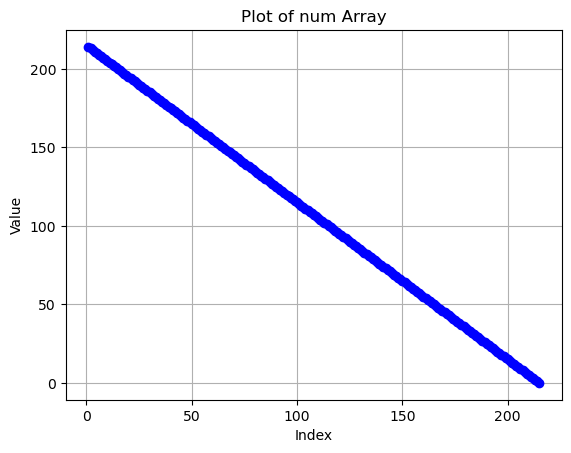

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Data to plot
num = clust_obj.den
# Create a figure and an axes.

x_values = np.arange(1, len(num) + 1)
fig, ax = plt.subplots()
# Plotting the data
ax.plot(
    x_values, num, marker="o", linestyle="-", color="b"
)  # 'o' is for circle markers

# Adding title and labels
ax.set_title("Plot of num Array")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
# ax.set_yscale("log")
# Show grid
ax.grid(True)

# Display the plot
plt.show()

In [ ]:
clust_obj.num

array([7.81324116e+00, 8.06403960e-01, 6.48734110e-01, 5.73428120e-01,
       5.18529560e-01, 4.31101080e-01, 3.65205650e-01, 1.93180650e-01,
       1.41207390e-01, 9.57577800e-02, 6.83051400e-02, 6.33053400e-02,
       5.62405400e-02, 4.33619600e-02, 3.14372200e-02, 2.46783000e-02,
       1.96785000e-02, 1.45421600e-02, 1.17554000e-02, 7.15315000e-03,
       5.04389000e-03, 1.67527000e-03, 4.17000000e-04, 0.00000000e+00])

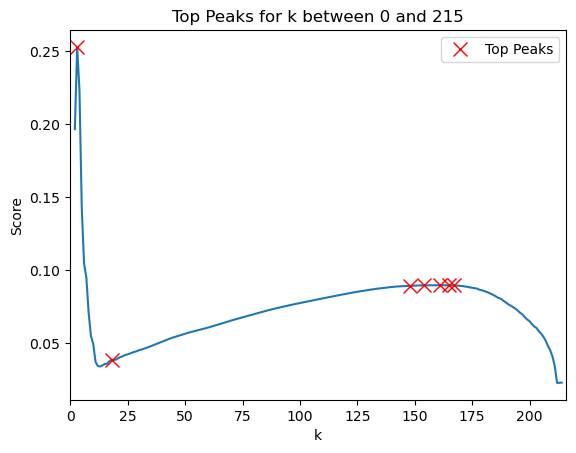

Found only 7 peak(s)


[3, 161, 165, 167, 154, 148, 18]

In [3]:
clust_obj = PhytClust(tree)
clust_obj.run()
clust_obj.score_calc(plot=False)
clust_obj.find_peaks(n=20)

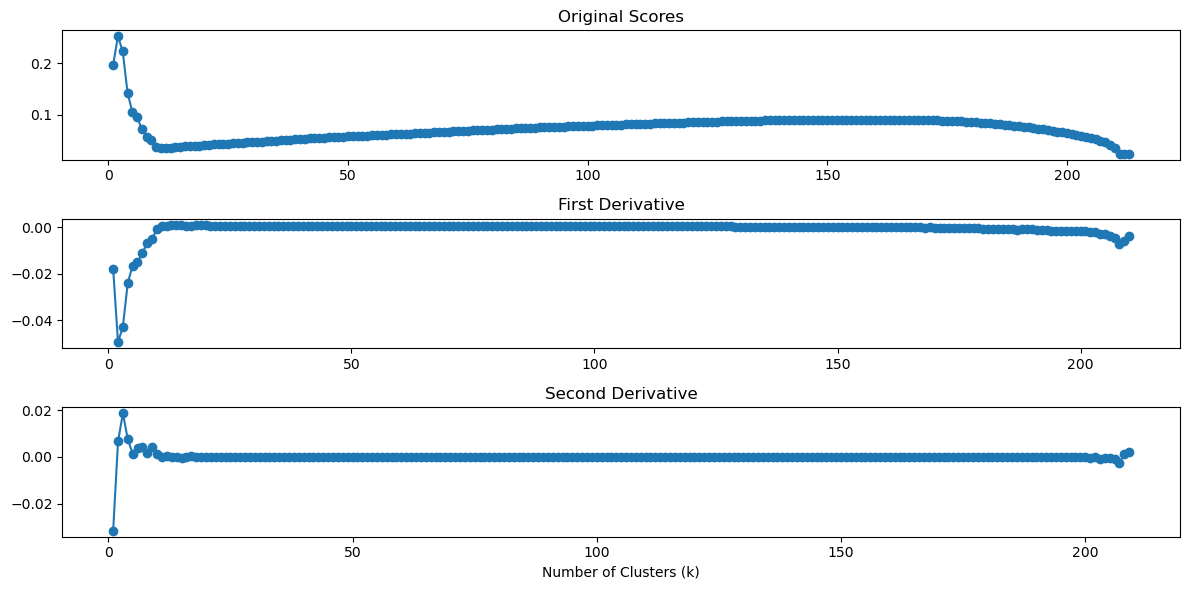

Best k based on increasing first derivative and positive second derivative: 4


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Example score data
scores = clust_obj.scores

# Calculate a moving average
window_size = 3
moving_avg = np.convolve(scores, np.ones(window_size) / window_size, mode="valid")

# Calculate first and second derivatives
first_derivative = np.diff(moving_avg, n=1)
second_derivative = np.diff(moving_avg, n=2)

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(311)
plt.plot(scores, "o-", label="Original Scores")
plt.title("Original Scores")
plt.subplot(312)
plt.plot(first_derivative, "o-", label="First Derivative")
plt.title("First Derivative")
plt.subplot(313)
plt.plot(second_derivative, "o-", label="Second Derivative")
plt.title("Second Derivative")
plt.xlabel("Number of Clusters (k)")
plt.tight_layout()
plt.show()

# Identify k with the highest first derivative that is still increasing (positive second derivative)
best_k = (
    np.argmax(first_derivative[:-1] * (second_derivative > 0)) + 1
)  # adjust indexing based on your data
print(
    f"Best k based on increasing first derivative and positive second derivative: {best_k + window_size}"
)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (x values and corresponding y values of the curve)
x = np.linspace(0, 10, 100)  # 100 points from 0 to 10
y = np.exp(-x) + np.random.normal(0, 0.01, 100)  # Exponential decay plus some noise

# Calculate the first derivative of y with respect to x
dy = np.diff(y) / np.diff(x)
x_mid = x[:-1] + np.diff(x) / 2  # mid-points of x for derivative calculation

# Define a threshold for "approaching zero"
threshold = 0.01

# Find where the curve first gets below the threshold and where derivative changes are small
below_threshold = np.where((np.abs(y) < threshold) & (np.abs(dy) < threshold))[0]

if len(below_threshold) > 0:
    stabilization_point = x[below_threshold[0]]
else:
    stabilization_point = None

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(x, y, label="y = exp(-x)")
plt.plot(x_mid, dy, label="First derivative (dy/dx)", linestyle="--")
plt.axhline(0, color="grey", lw=0.5)
plt.axvline(
    stabilization_point,
    color="red",
    linestyle=":",
    label=f"Stabilization at x={stabilization_point}",
)
plt.title("Analysis of Curve Approaching Zero")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Output the result
if stabilization_point is not None:
    print(
        f"The curve approaches zero and stabilizes around x = {stabilization_point:.2f}"
    )
else:
    print("No stabilization point found within the threshold limits.")

ValueError: operands could not be broadcast together with shapes (100,) (99,) 

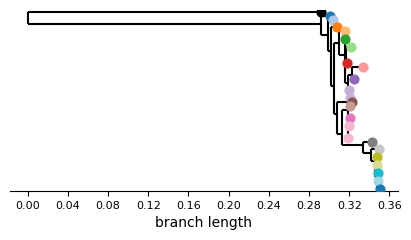

In [ ]:
clust_obj.plot(height_scale= 0.2, n=21)

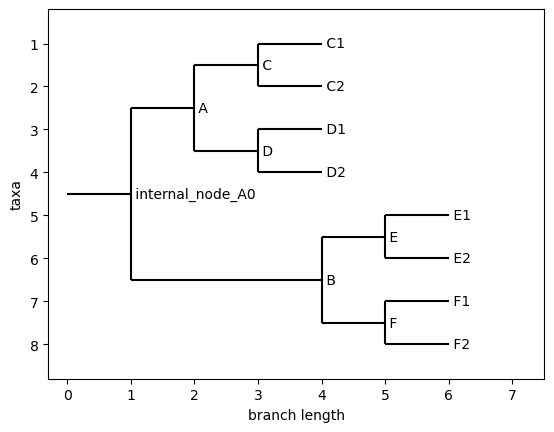

In [ ]:
Phylo.draw(tree)

In [ ]:
clust_obj = PhytClust(tree, score_type="CH_score", outgroup="HIV-1 HXB2 - env gene")
clust_obj.run()
clust_obj.score_calc(plot = False)
clust_obj.find_peaks()

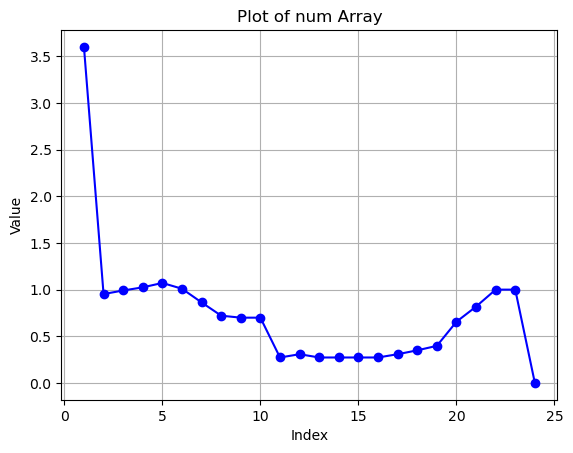

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data to plot
num = clust_obj.num
# Create a figure and an axes.

x_values = np.arange(1, len(num) + 1)
fig, ax = plt.subplots()
# Plotting the data
ax.plot(x_values, num, marker="o", linestyle="-", color="b")  # 'o' is for circle markers

# Adding title and labels
ax.set_title("Plot of num Array")
ax.set_xlabel("Index")
ax.set_ylabel("Value")

# Show grid
ax.grid(True)

# Display the plot
plt.show()

In [ ]:
def run_clustering():
    clust_obj = PhytClust(
        tree,
        outgroup="Archaea_Micrarchaeota_ARMAN_Candidatus_Micrarchaeum_acidiphilum_ARMAN2",
    )
    clust_obj.run()
    clust_obj.score_calc(plot = False)
    clust_obj.find_peaks()
import cProfile
#cProfile.run("run_clustering()")



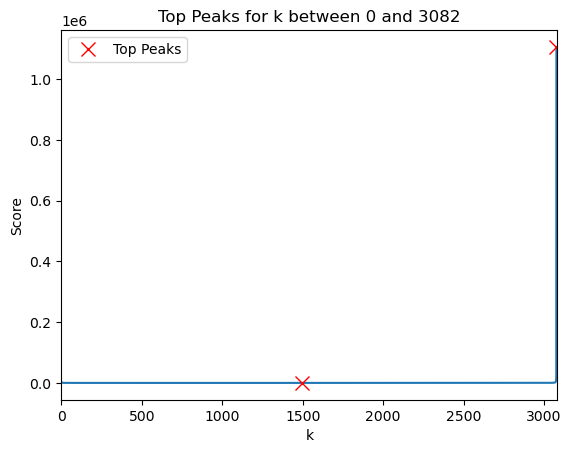

Found only 2 peak(s)


In [ ]:
import cProfile
import pstats

# Create a Profile object
profiler = cProfile.Profile()
profiler.enable()

# Run your function
run_clustering()

profiler.disable()

# Save the stats to a file
profiler.dump_stats("profile_stats.prof")

In [ ]:
# Load the stats
stats = pstats.Stats("profile_stats.prof")

# Sort the statistics by cumulative time
stats.sort_stats("cumtime")

# Print the stats report
stats.print_stats()

# Alternatively, you can print only a few lines
# stats.print_stats(10)  # For example, the top 10 lines

Wed Apr 17 15:43:54 2024    profile_stats.prof

         387255327 function calls (336738144 primitive calls) in 106.682 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000  106.682   53.341 /home/ganesank/ENTER/envs/medicc_env/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3469(run_code)
     14/2    0.000    0.000  106.682   53.341 {built-in method builtins.exec}
        1    0.048    0.048  106.682  106.682 /tmp/ipykernel_375413/2820383042.py:9(<module>)
        1    0.000    0.000  106.633  106.633 /tmp/ipykernel_375413/2667600103.py:1(run_clustering)
        1    0.000    0.000   90.642   90.642 /home/ganesank/project/phytclust/phytclust/phytclust.py:230(run)
        1    0.000    0.000   90.642   90.642 /home/ganesank/project/phytclust/phytclust/phytclust.py:224(def_clusters)
        1    0.009    0.009   90.642   90.642 /home/ganesank/project/phytclust/phytclust/phytclust.py:22

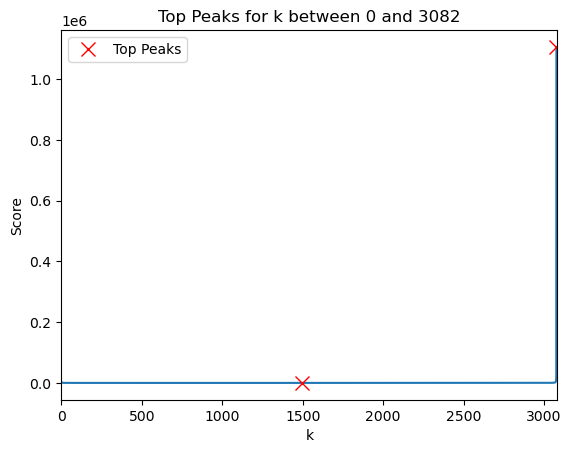

Found only 2 peak(s)


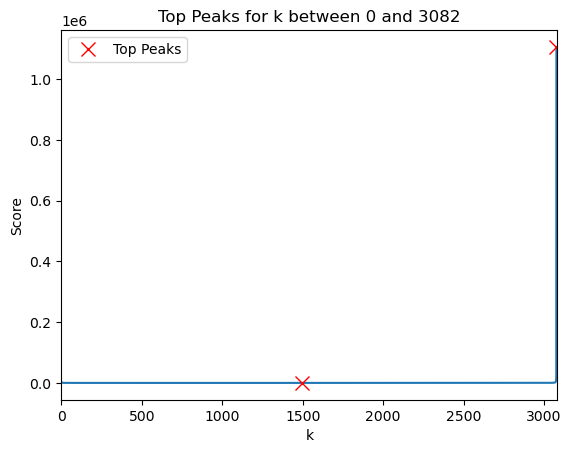

Found only 2 peak(s)


AttributeError: 'LineStats' object has no attribute 'stream'

In [ ]:
from line_profiler import LineProfiler

# Create a LineProfiler object
profiler = LineProfiler()

# Profile the first function
profiler.add_function(PhytClust.run)
clust_obj = PhytClust(
    tree,
    outgroup="Archaea_Micrarchaeota_ARMAN_Candidatus_Micrarchaeum_acidiphilum_ARMAN2",
)
profiler.run("clust_obj.run()")

# Profile the second function
profiler.add_function(PhytClust.score_calc)
clust_obj.score_calc(plot=False)
profiler.run("clust_obj.score_calc(plot=False)")

# Profile the third function
profiler.add_function(PhytClust.find_peaks)
clust_obj.find_peaks()
profiler.run("clust_obj.find_peaks()")

# Get the profiling results
result_str = profiler.get_stats().stream.getvalue()

# Sort the results by cumulative time (cumtime)
sorted_results = sorted(
    result_str.split("\n"), key=lambda x: float(x.split()[2]), reverse=True
)

# Save the sorted results to a text file
with open("profiling_results.txt", "w") as f:
    f.write("\n".join(sorted_results))

# Print the sorted results
print("\n".join(sorted_results))

In [ ]:
from line_profiler import LineProfiler
from io import StringIO

# Create a LineProfiler object
profiler = LineProfiler()

# Profile the functions
profiler.add_function(PhytClust.run)

profiler.run("clust_obj.run()")

profiler.add_function(PhytClust.score_calc)
clust_obj.score_calc(plot=False)
profiler.run("clust_obj.score_calc(plot=False)")

# profiler.add_function(PhytClust.find_peaks)
# clust_obj.find_peaks()
# profiler.run("clust_obj.find_peaks()")

# Capture the profiling results in a string
stream = StringIO()
profiler.print_stats()


Timer unit: 1e-09 s

Total time: 110.145 s
File: /home/ganesank/project/phytclust/phytclust/phytclust.py
Function: run at line 230

Line #      Hits         Time  Per Hit   % Time  Line Contents
   230                                               def run(self, verbose=False):
   231                                                   # print(f"self.k = {self.k}, self.max_k = {self.max_k}")  # Debug
   232         1       2946.0   2946.0      0.0          start_time = time.time()
   233         1       1023.0   1023.0      0.0          if self.max_k is None and self.k:
   234                                                       self.clusters = self.tree_clust_backtrack(self.k, verbose=verbose)
   235                                           
   236         1        734.0    734.0      0.0          elif self.k is None:
   237         1        719.0    719.0      0.0              if self.max_k is None or self.max_k == "max":
   238                                                         

In [ ]:
prominence_start = 0.01 * (np.nanmax(clust_obj.scores) - np.nanmin(clust_obj.scores))

In [ ]:
%load_ext line_profiler
%lprun -f PhytClust.__init__ clust_obj = PhytClust(tree, outgroup="Archaea_Micrarchaeota_ARMAN_Candidatus_Micrarchaeum_acidiphilum_ARMAN2")


In [ ]:
%lprun -f def_clusters run(parameters)

UsageError: Could not find module def_clusters.
NameError: name 'def_clusters' is not defined


In [ ]:
result_str = stream.getvalue()

In [ ]:
sorted_results = sorted(
    result_str.split("\n"),
    key=lambda x: (
        float(x.split()[2]) if len(x.split()) > 2 else float("inf")
    ),  # Use float('inf') if unable to convert to float
    reverse=True,
)

# Save the sorted results to a text file
with open("profiling_results.txt", "w") as f:
    f.write("\n".join(sorted_results))

# Print the sorted results
print("\n".join(sorted_results))

ValueError: could not convert string to float: 'at'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
data = clust_obj.num
# Create a time axis that starts at 1 and increments by 1 for each data point
t = np.arange(1, len(data) + 1)

# Plot the data
plt.figure(figsize=(10, 6))  # Optional: Adjust the figure size
plt.plot(
    t, data,linestyle="-", color="b"
)  # You can customize the plot with these parameters
plt.title("Data Measurement Over Time")
plt.xlabel("Time (t)")
plt.ylabel("Measurement")
plt.grid(True)  # Optional: Show grid
plt.show()

In [ ]:
beta

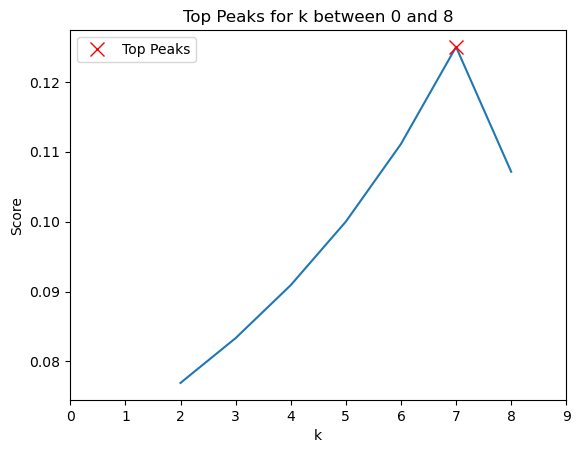

Found only 1 peak(s)


[7]

In [ ]:
# find number of peaks
clust_obj.find_peaks(n=10)
# # find peaks within a range
# clust_obj.find_peaks(k_start=15, k_end=60)

In [ ]:
clust_obj.plot(
    n=22,
    width_scale=2,
    height_scale=0.3,
    show_branch_lengths=False,
    hide_internal_nodes=True,
    outlier=False,
    marker_size=50
    # save=True,
    # results_dir=results_dir,
)

In [ ]:
clust_obj.dp_table

{Clade(branch_length=1.0, name='A'): array([ 1., inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
        inf, inf]),
 Clade(branch_length=1.0, name='B'): array([ 1., inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
        inf, inf]),
 Clade(branch_length=1.4, name='internal_node_N0'): array([3.4, 2. , inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
        inf, inf]),
 Clade(branch_length=1.0, name='C'): array([ 1., inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
        inf, inf]),
 Clade(branch_length=1.0, name='internal_node_M0'): array([6.8, 4.4, 3. , inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
        inf, inf]),
 Clade(branch_length=1.0, name='D'): array([ 1., inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
        inf, inf]),
 Clade(branch_length=1.0, name='internal_node_L0'): array([10.8,  7.8,  5.4,  4. ,  inf,  inf,  inf,  inf,  inf,  inf,  inf,
         inf,  inf,  inf,  inf]),
 Clade(branch_length=1.0, name='E'): 

In [ ]:
# plot with labels
import matplotlib.pyplot as plt 
plt.rcParams.update({"font.size": 8})

label_func = lambda x: x.name if hasattr(x, "name") else x

clust_obj.plot(
    save=True,
    results_dir="/home/ganesank/project/phytclust/results",  # results_dir
    show_terminal_labels=True,
    outlier=False,
    top_n=1,
    label_func=label_func,
    width_scale=8,
    height_scale=0.4,
    marker_size=40,
)

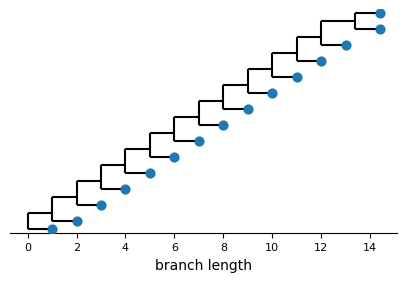

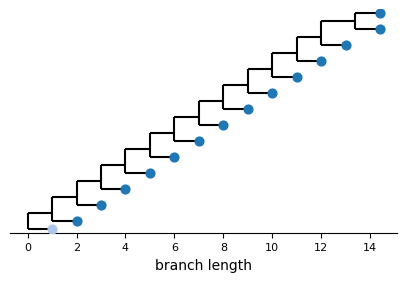

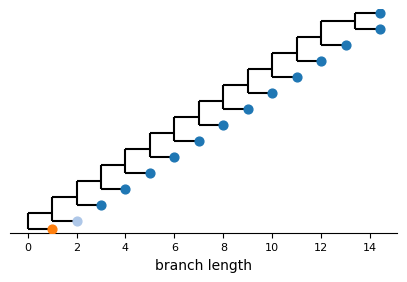

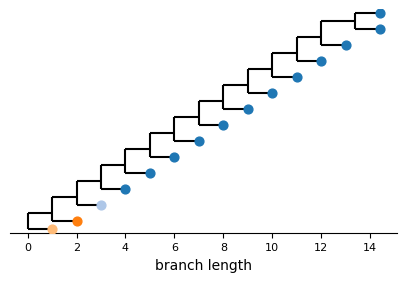

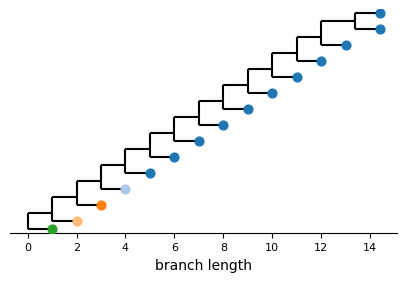

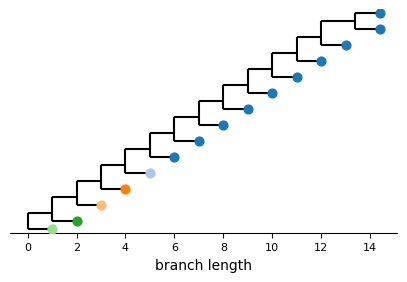

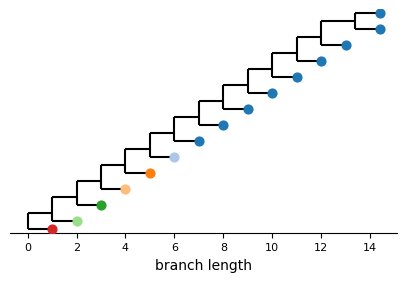

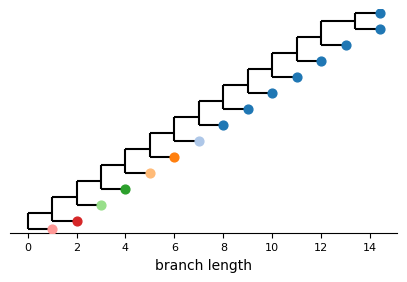

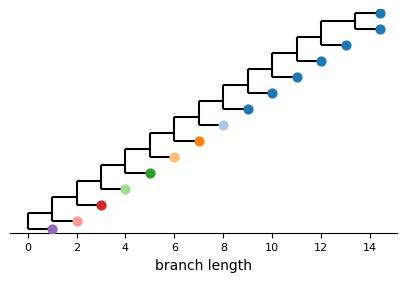

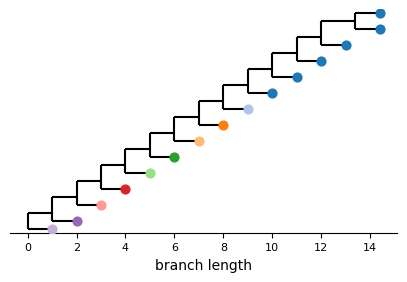

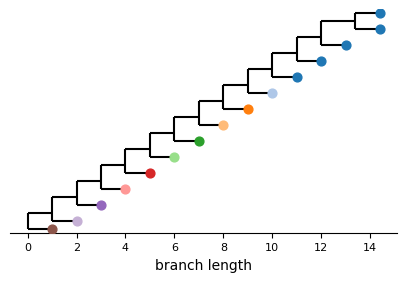

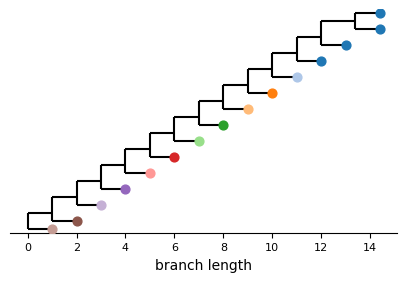

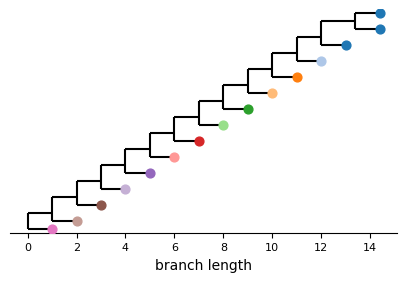

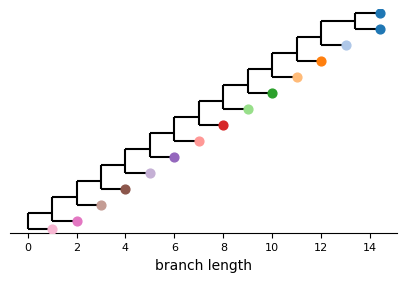

In [ ]:
# plot for all k values
for n in range(1, len(tree.get_terminals())):
    clust_obj.plot(
        n=n,
        height_scale=0.4,
        outlier=False,
        save=False,
        results_dir="/home/ganesank/project/phytclust/results",
    )

In [ ]:
clust_obj.save(results_dir=results_dir)

In [ ]:
TreeCluster.py -i project/subclone_detection/phylogenie/output_directory_2/k_50_n_500_unit_1_bf_0.5_20240408_153843/iteration_26/supertree.newick -m max_clade -tf argmax_clusters -t 1000 -o /home/ganesank/project/phytclust/example_data/test_tree.csv

In [ ]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO
import seaborn as sns
import pandas as pd

In [ ]:
tree = Phylo.read(StringIO("(A, (B, C),(D, E))"), "newick")

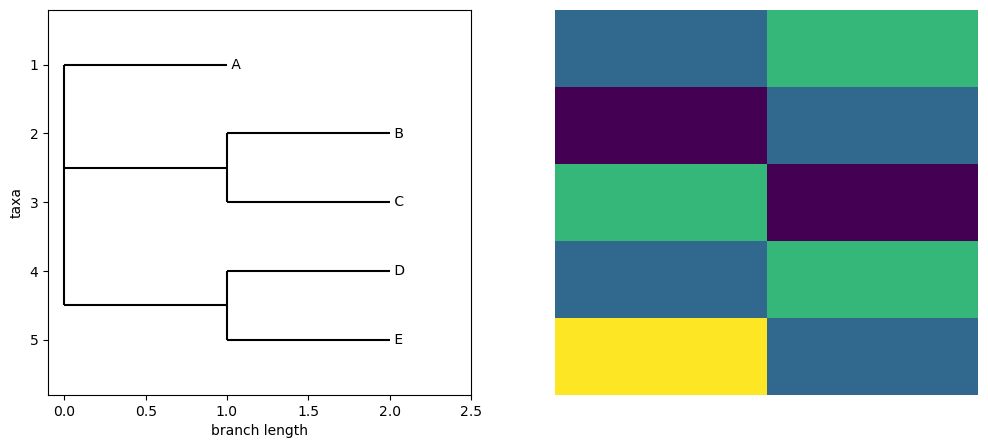

In [ ]:
data = {
    "Clade": ["A", "B", "C", "D", "E"],
    "Cluster1": [1, 0, 2, 1, 3],
    "Cluster2": [2, 1, 0, 2, 1],
}
df = pd.DataFrame(data).set_index("Clade")

# Create a composite figure
fig = plt.figure(figsize=(12, 5))

# Add a subplot for the tree (1x2 grid, first subplot)
ax1 = fig.add_subplot(1, 2, 1)
Phylo.draw(tree, do_show=False, axes=ax1)

# Add a subplot for the heatmap (1x2 grid, second subplot)
ax2 = fig.add_subplot(1, 2, 2)
sns.heatmap(df, cmap="viridis", ax=ax2, cbar=False)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_ylabel('')
plt.show()

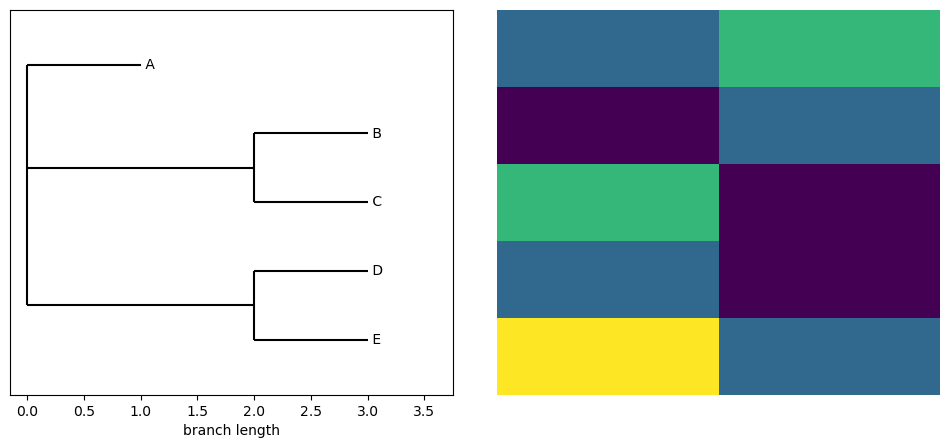

In [ ]:
import matplotlib.pyplot as plt
from Bio import Phylo
from io import StringIO
import seaborn as sns
import pandas as pd

tree = Phylo.read(StringIO("(A:1,(B:1,C:1):2,(D:1,E:1):2)"), "newick")

# Example clustering data
data = {
    "Clade": ["A", "B", "C", "D", "E"],
    "Cluster1": [1, 0, 2, 1, 3],
    "Cluster2": [2, 1, 0, 0, 1],
}
df = pd.DataFrame(data).set_index("Clade")

# Create a composite figure
fig = plt.figure(figsize=(12, 5))

# Add a subplot for the tree (1x2 grid, first subplot)
ax1 = fig.add_subplot(1, 2, 1)
Phylo.draw(tree, do_show=False, axes=ax1)

# # Remove the boundary (spines) around the phylogenetic tree
# for spine in ax1.spines.values():
#     spine.set_visible(False)

# Remove ticks (if you haven't already)
# ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_ylabel('')
# Add a subplot for the heatmap (1x2 grid, second subplot)
ax2 = fig.add_subplot(1, 2, 2)
sns.heatmap(
    df, cmap="viridis", ax=ax2, cbar=False
)  # Set cbar=False to remove the color bar


# Remove ticks and labels from the x-axis
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_ylabel("")
# Adjust subplot spacing
plt.subplots_adjust(
    wspace=0.1
)  # Adjust this value as needed to move subplots closer or further apart

plt.show()

In [ ]:
tree

Tree(rooted=False, weight=1.0)

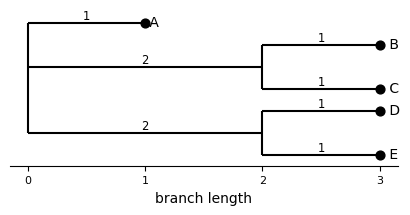

In [ ]:
# Add a subplot for the tree (1x2 grid, first subplot)
ax1 = fig.add_subplot(1, 2, 1)
plot_tree(tree, hide_internal_nodes=True)

# # Remove the boundary (spines) around the phylogenetic tree
# for spine in ax1.spines.values():
#     spine.set_visible(False)

# Remove ticks (if you haven't already)
# ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_ylabel("")
# Add a subplot for the heatmap (1x2 grid, second subplot)
ax2 = fig.add_subplot(1, 2, 2)
sns.heatmap(
    df, cmap="viridis", ax=ax2, cbar=False
)  # Set cbar=False to remove the color bar


# Remove ticks and labels from the x-axis
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_ylabel("")
# Adjust subplot spacing
plt.subplots_adjust(
    wspace=0.1
)  # Adjust this value as needed to move subplots closer or further apart

plt.show()

In [ ]:
import numpy as np
rows = 5 
cols = 4 
array = np.random.randint(2, size=(rows, cols))
print(array)

[[0 1 1 0]
 [1 0 0 0]
 [1 1 0 0]
 [0 1 0 0]
 [1 1 1 0]]


In [ ]:
import numpy as np

def split_array(input_array, n):
    rows, cols = input_array.shape
    output_arrays = [np.zeros((rows, cols), dtype=int) for _ in range(n)]

    for i in range(rows):
        for j in range(cols):
            value = input_array[i][j]
            for k in range(min(n, value)):
                output_arrays[k][i][j] = 1

    return output_arrays

input_array = np.array([[3, 2, 2], [1, 4, 2]])
n = 5 

output = split_array(input_array, n)

for idx, arr in enumerate(output):
    print(f"Array {idx+1}:\n{arr}\n")

Array 1:
[[1 1 1]
 [1 1 1]]

Array 2:
[[1 1 1]
 [0 1 1]]

Array 3:
[[1 0 0]
 [0 1 0]]

Array 4:
[[0 0 0]
 [0 1 0]]

Array 5:
[[0 0 0]
 [0 0 0]]

